# 자기회귀누적이동평균 모델 정의

- 자기회귀누적이동평균 프로세스(autoregressive integrated moving average process)는 자기회귀과정 AR(p), 적분 I(d), 이동평균과정 MA(q)의 조합임

- ARMA 프로세스와 마찬가지로 ARIMA 프로세스는 현재의 값이 AR(p) 부분에서 나오는 과거의 값과 MA(q) 부분에서 나오는 과거 오차에 따라 달라진다는 것을 나타냄

- 그러나 ARIMA 프로세스는 $y_t$ 로 표현되는 원본 수열을 사용하는 대신 $y'_t$ 로 표시되는 차분된 수열을 사용
    - $$y'_t = C + \phi_1 y'_{t-1} + \cdots + \phi_p y'_{t-p} + \theta_1\epsilon'_{t-1} + \cdots + \theta_q\epsilon'_{t-q} + \epsilon_t$$
        
        - $y'_t$ : 차분된 수열의 현재값
        - $C$ : 상수
        - $\phi_p y'_{t-p}$ : 차분된 수열의 과거값
        - $\mu$ : 차분된 수열의 평균
        - $\theta_q\epsilon'_{t-q}$ : 과거 오차 항
        - $\epsilon_t$ : 현재 오차항

- ARMA 프로세스와 마찬가지로 차수 p는 모델에 포함할 시계열 중 지연된 값의 개수를 결정

- 차수 q는 모델에 포함하는 지연된 오차 항의 개수를 결정

- 차수 d는 수식에서 표현되어 있지는 않음

- 차수 d는 적분 차수
    - 적분은 차분의 반대
    - 따라서 적분의 차수는 수열을 정상적으로 만들기 위해 차분한 횟수와 같음
    - 예) 수열을 한 번 차분하여 정상성을 만족하면 d = 1, 수열을 두 번 차분하여 정상성을 만족하면 d = 2가 됨

- 차분을 적용하면 정상적으로 만들 수 있는 시계열을 적분된 수열(integrated series)이라고 함

- 비정상적 적분 시계열의 경우, ARIMA(p, d, q) 모델을 사용하여 예측을 수행할 수 있음

- 간단히 말하면 ARIMA 모델은 비정상 시계열에 적용할 수 있는 ARMA 모델이라고도 할 수 있음
    - 적분 차수 d를 구하기만 하면 ARIMA(p, d, q) 모델을 비정상 시계열에 사용할 수 있음

# 일반적 모델링 절차 수정

- ARIMA(p, d, q) 모델을 사용하기 위해서는 일반적 모델링 절차에 적분 차수 d를 결정하는 단계를 포함해야 함

- 적분 차수 d는 시계열이 정상성을 만족하기 위해 차분해야 하는 최소 횟수

- 시계열에 변환을 적용할 때 d의 값을 시계열의 차분 횟수로 설정하는 단계 추가
    - 이후 ARMA(p, q) 모델을 훈련하는 대신 ARIMA(p, d, q) 모델을 훈련
    - 그 외 절차는 동일(AIC사용하여 최적 모델 선택, 잔차 분석)

- d = 0인 경우에는 ARMA(p, q) 모델과 동일함
    - 시계열이 정상적이기 위해 차분할 필요가 없다는 뜻
    - d = 0으로 설정하면 ARIMA(p, d, q) 모델을 차분되지 않은 수열에도 적용할 수 있음

<img src = "./image/arima모델링_절차.png" height = 600 width = 600>

# 비정상 시계열 예측

- 위 그림의 절차를 적용하여 존슨앤드존슨의 분기별 주당순이익을 예측

- 1년간의 분기별 주당순이익을 예측
    - 1년은 4분기가 있기 때문에 향후 4번의 timestep을 예측

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./data/jj.csv")

In [3]:
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


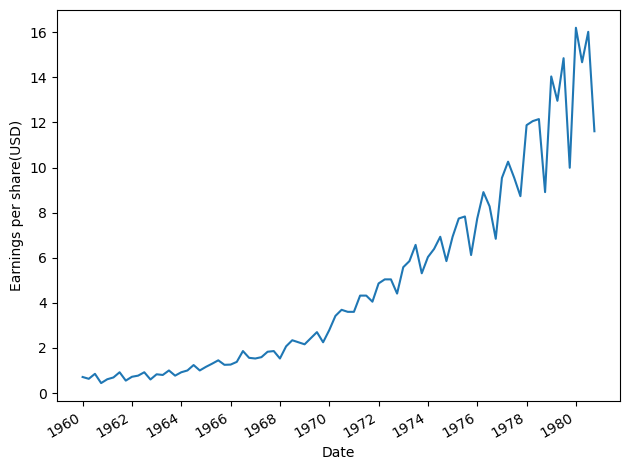

In [4]:
# 1960 ~ 1980년 존슨앤드존슨 분기별 주당순이익(EPS)
fig, ax = plt.subplots()

ax.plot(df["date"], df["data"])

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share(USD)")
# ax.axvspan(80, 83, color = "#808080", alpha = 0.1)

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

- 절차에 따라 데이터가 정상적인지 확인해야 함

In [5]:
ad_fuller_result = adfuller(df["data"])

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: 2.7420165734574713
p-value: 1.0


- p-value가 0.05보다 크므로 귀무가설을 기각할 수 없으며, 수열이 비정상적이라는 뜻

- 적분 차수 d를 설정하기 위해 우선 1차 차분을 적용하고 정상성 테스트

In [6]:
# 1차 차분 후 정상성 테스트
eps_diff = np.diff(df["data"], n = 1)

ad_fuller_result = adfuller(eps_diff)

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -0.40740976363803383
p-value: 0.9088542416911326


- p-value가 0.05보다 크기 때문에 귀무가설을 기각할 수 없으며, 비정상 시계열임

- 2차 차분 적용하고 정상성 테스트

In [7]:
# 2차 차분 후 정상성 테스트
eps_diff2 = np.diff(eps_diff, n = 1)

ad_fuller_result = adfuller(eps_diff2)

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -3.585162874793165
p-value: 0.0060510998696034725


- p-value가 0.05보다 작으므로 시계열이 정상성을 만족함

- 정상성을 만족하기 위해 두 번 차분했으므로 적분 차수는 2이고 d = 2임

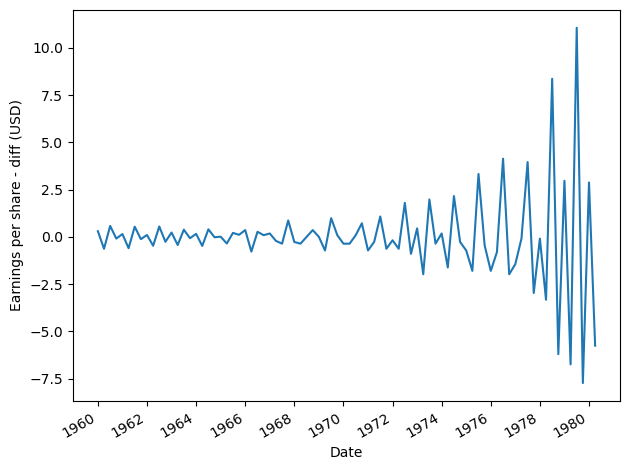

In [8]:
# 2차 차분 시계열 시각화
fig, ax = plt.subplots()

ax.plot(df["date"][2:], eps_diff2)

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share - diff (USD)")
# ax.axvspan(80, 83, color = "#808080", alpha = 0.1)

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

- 다양한 조합의 ARIMA(p, d, q) 모델을 훈련하기 전에 데이터 분할
    - 1960 ~ 1979년까지의 데이터를 훈련 데이터
    - 1980년의 데이터를 테스트 데이터로 분할

- 여러 ARIMA(p, d, q) 모델을 훈련하기 위한 함수 정의

In [11]:
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    '''
    endog : 예측하고자 하는 대상 시계열 데이터
    order_list : p, q 조합 리스트
    d : 적분 차수
    '''
    results = [] # 차수 p, q와 그에 해당하는 AIC를 저장할 리스트

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order = (order[0], d, order[1])).fit(disp = False)

        except:
            continue

        aic = model.aic # 모델의 AIC를 계산
        results.append([order, aic]) # 결과 리스트에 p, q 조합과 AIC를 추가

    result_df = pd.DataFrame(results)
    result_df.columns = ["(p, q)", "AIC"]

    # 오름차순 정렬, AIC가 낮을수록 좋음
    result_df = result_df.sort_values(by = "AIC", ascending = True).reset_index(drop = True)

    return result_df

- 이번 예시에서는 두 차수에 대해 0, 1, 2, 3 값을 시도

In [12]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
d = 2

order_list = list(product(ps, qs))

In [13]:
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

- d는 구체적인 특정값으로 정해진 값이기 때문에 범위를 지정하지 않음

- AIC를 사용하여 모델을 비교하려면 d는 항상 일정해야함

In [14]:
train = df["data"][:-4]

result_df = optimize_ARIMA(train, order_list, d)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p, q)",AIC
0,"(3, 3)",115.269399
1,"(3, 1)",115.624980
2,"(3, 2)",115.672007
3,"(3, 0)",154.430656
4,"(0, 3)",194.654716
5,"(0, 2)",209.274505
6,"(2, 3)",220.666884
7,"(1, 3)",228.267819
8,"(1, 2)",228.935882
9,"(2, 2)",229.974718


In [21]:
model = SARIMAX(train, order = (3, 2, 3))
model_fit = model.fit(disp = False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   80
Model:               SARIMAX(3, 2, 3)   Log Likelihood                 -50.635
Date:                Thu, 16 Jul 2026   AIC                            115.269
Time:                        16:19:43   BIC                            131.766
Sample:                             0   HQIC                           121.873
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9995      0.037    -27.340      0.000      -1.071      -0.928
ar.L2         -0.9883      0.039    -25.176      0.000      -1.065      -0.911
ar.L3         -0.9765      0.025    -38.509      0.0

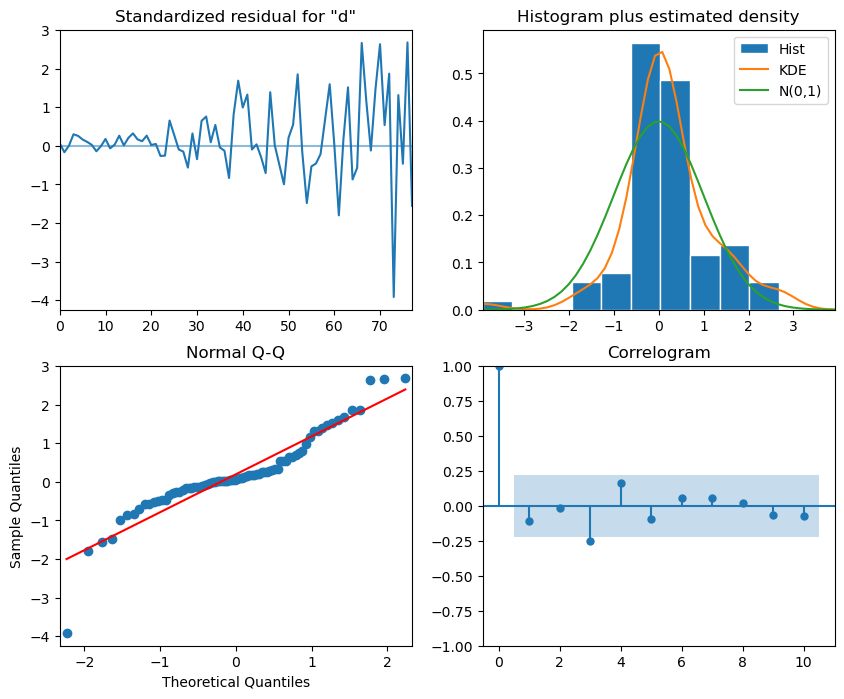

In [22]:
# 잔차 분석
model_fit.plot_diagnostics(figsize = (10, 8))
plt.show()

- 우측 상단 잔차의 분포를 통해 정규분포와 유사하다는 것을 확인

- Q-Q plot 은 끝부분에 약간의 편차가 있지만 전반적으로 직선적인 선이 표시됨

- 상관관계도에서는 지연 3에서 계수가 유의한 것으로 보이지만 그 이전에 유의한 자기상관계수가 없기 때문에 우연에 의한 것으로 추정
    - 지연 0 이후에는 유의한 계수가 나타나지 않음
 
- 정성적 관점에서 보면 잔차가 백색소음에 가까운 것으로 보이며, 모델의 오차가 무작위적이라는 뜻임

In [23]:
# 융-박스 테스트
residuals = model_fit.resid

rt = acorr_ljungbox(residuals, np.arange(1, 11, 1))
print(rt)

      lb_stat  lb_pvalue
1    1.617799   0.203399
2    1.619436   0.444984
3    7.175166   0.066519
4    9.113188   0.058332
5    9.731617   0.083207
6    9.976705   0.125636
7   10.234855   0.175651
8   10.265709   0.246870
9   10.609308   0.303442
10  11.048203   0.353775


- 잔차의 첫 10개 지연에 대해 융-박스 테스트를 실행하면 모두 0.05보다 큰 p-value가 나오므로 귀무가설을 기각하지 않고 백색소음과 마찬가지로 상관관계가 없다고 결론

- ARIMA(3, 2, 3) 모델은 모든 검사를 통과했으며 예측에 사용할 수 있음
    - 평가 기준 베이스라인 모델은 단순 계절적 방법(1979년 1분기 값을 1980년 1분기 값으로 예측)

In [24]:
test = df.iloc[-4:]

test["naive_seasonal"] = df["data"].iloc[76:80].values
test

,date,data,naive_seasonal
80,1980-01-01,16.20,14.04
81,1980-04-01,14.67,12.96
82,1980-07-02,16.02,14.85
83,1980-10-01,11.61,9.99


In [25]:
ARIMA_pred = model_fit.get_prediction(80, 83).predicted_mean # 80번째 시점부터 83번째 시점까지의 예측값 계산

In [26]:
test["ARIMA_pred"] = ARIMA_pred
test

,date,data,naive_seasonal,ARIMA_pred
80,1980-01-01,16.20,14.04,15.860484
81,1980-04-01,14.67,12.96,14.380201
82,1980-07-02,16.02,14.85,16.368889
83,1980-10-01,11.61,9.99,11.676529


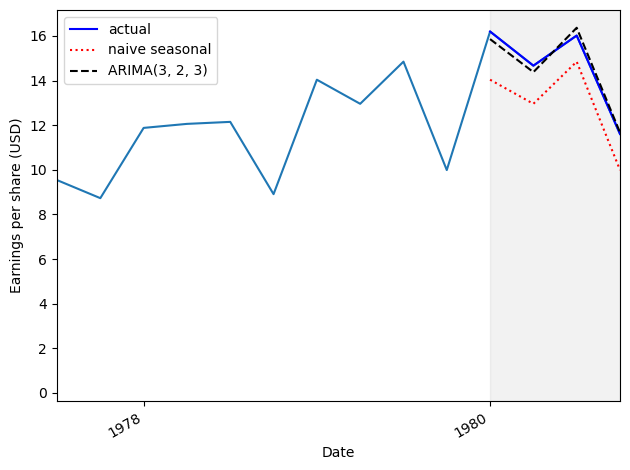

In [31]:
# 예측값 비교 시각화
fig, ax = plt.subplots()

ax.plot(df["date"], df["data"])
ax.plot(test["data"], "b-", label = "actual")
ax.plot(test["naive_seasonal"], "r:", label = "naive seasonal")
ax.plot(test["ARIMA_pred"], "k--", label = "ARIMA(3, 2, 3)")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")
ax.axvspan(80, 83, color = "#808080", alpha = 0.1)

ax.legend()

plt.xticks(np.arange(0, 81, 8), np.arange(1960, 1981, 2))
ax.set_xlim(70, 83)

fig.autofmt_xdate() # 겹치는 X축 날짜 라벨을 자동으로 회전 및 정렬하여 시인성을 높여줌
plt.tight_layout()

plt.show()

- ARIMA(3, 2, 3) 모델의 예측이 실제 관측값과 거의 완벽하게 겹쳐짐

In [32]:
# MAPE 측정
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [33]:
mape_naive_seasonal = mape(test["data"], test["naive_seasonal"])
mape_ARIMA = mape(test["data"], test["ARIMA_pred"])

print(mape_naive_seasonal, mape_ARIMA)

11.561658552433654 1.7055250388949665


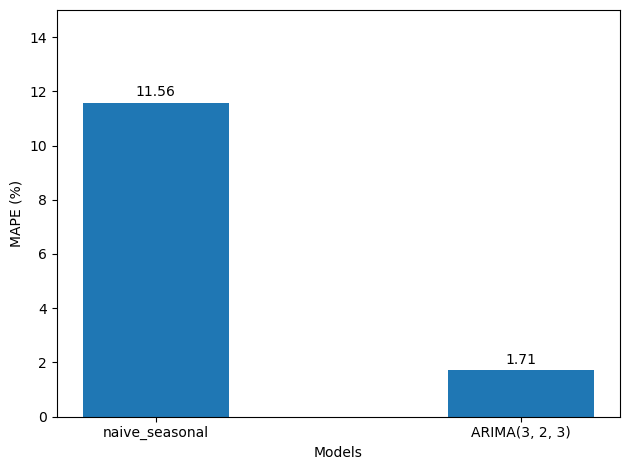

In [34]:
fig, ax = plt.subplots()

x = ["naive_seasonal", "ARIMA(3, 2, 3)"]
y = [mape_naive_seasonal, mape_ARIMA]

ax.bar(x, y, width = 0.4)
ax.set_xlabel("Models")
ax.set_ylabel("MAPE (%)")
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

- 단순한 계절 예측의 MAPE는 11.56%, ARIMA(3, 2, 3) 모델의 MAPE는 1.71%
    - 약 5분의 1 수준 오차
 
- ARIMA(3, 2, 3) 모델이 단순한 계절적 방법보다 더 나은 모델임을 확인

# 연습문제

## Chapter7

- Chapter7의 widget_sales 데이터에 ARIMA(p, d, q) 모델링 절차 적용해보기

- 테스트 데이터는 마지막 50 timestep